/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Sigma shape: (950, 2)
CUSUM aligned shape: (950,)
Labels shape: (950,)


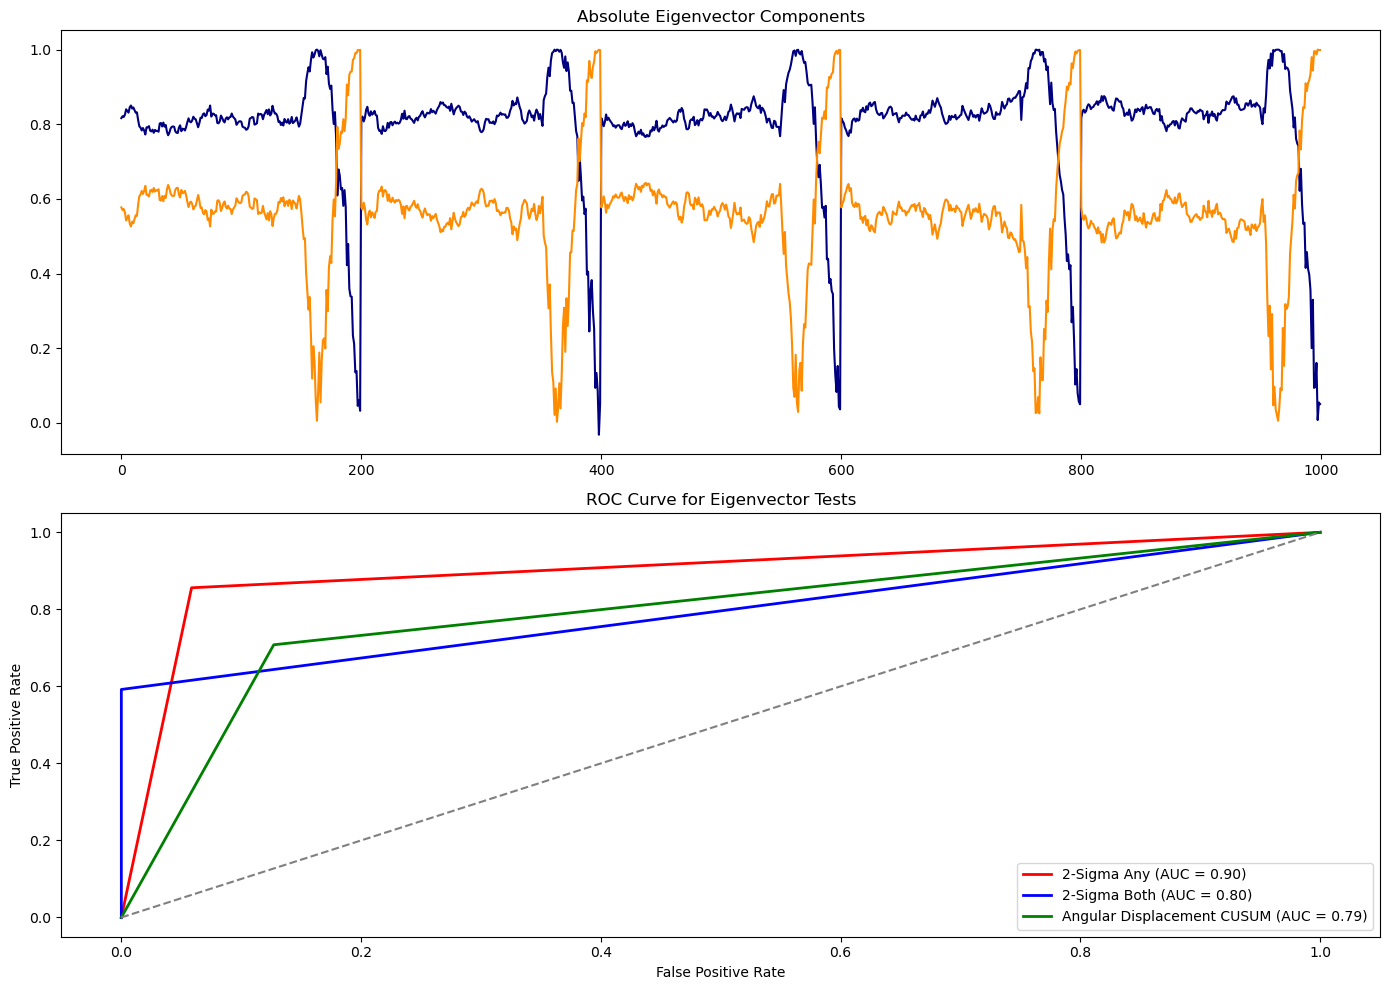

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from sklearn.metrics import roc_curve, auc

def generate_2d_eigenvector_ts(n_periods=1000, segment_length_1=150, segment_length_2=50, seed=42):
    # Init system state
    np.random.seed(seed)
    vecs = []
    change_points = []
    alpha = 0.9
    noise_std = 0.01
    i = 0
    t = 0

    # Generate segments of time series
    # Alternating between stationary and non-stationary segments
    while t < n_periods:
        if i % 2 == 0:
            seg_len = min(segment_length_1, n_periods - t)
            segment = np.zeros((seg_len, 2))
            segment[0] = [np.sqrt(2/3), -np.sqrt(1/3)]
            for j in range(1, seg_len):
                segment[j,0] = alpha * segment[j - 1,0] + (1-alpha)*segment[0,0] + np.random.normal(0, noise_std)
                segment[j,1] = -np.sqrt(1 - segment[j,0]**2)
        else:
            seg_len = min(segment_length_2, n_periods - t)
            drift_angle_start = np.arcsin(vecs[-1][0])
            drift = np.linspace(drift_angle_start, np.pi, seg_len) + np.random.normal(0,0.05,(seg_len,2))
            segment = np.zeros((seg_len, 2))
            segment[:, 0] = np.sin(drift[:,0])
            segment[:, 1] = np.cos(drift[:,0])

        # Get absolute eigenvector components and update system state
        segment[:,1] = np.abs(segment[:,1])
        vecs.append(segment)
        t += segment.shape[0]
        i += 1
        change_points.append(t)

    vecs = np.vstack(vecs)
    return vecs, change_points[:-1]

def cusum(data, threshold=3, drift=0, noise_std=0.01):
    pos_cusum = np.zeros(len(data))
    signal_indices = np.zeros(len(data))
    for i in range(1, len(data)):
        pos_cusum[i] = max(0, pos_cusum[i-1] + data[i] - drift-noise_std)
        if pos_cusum[i] > threshold * noise_std:
            pos_cusum[i] = 0  # Reset after signal
            signal_indices[i] = 1
    return signal_indices

def cossine_sim(ts):
    n_variables = ts.shape[1]
    cos_sims = []

    for i in range(1, len(ts)):
        dot_product = np.dot(ts[i-1], ts[i])
        norm_product = np.linalg.norm(ts[i-1]) * np.linalg.norm(ts[i])
        cos_sim = dot_product / norm_product
        cos_sims.append(cos_sim)

    return np.array(cos_sims)

def angle_displacement(ts):
    n_variables = ts.shape[1]
    angle_displacements = []

    for i in range(1, len(ts)):
        dot_product = np.dot(ts[i-1], ts[i])
        norm_product = np.linalg.norm(ts[i-1]) * np.linalg.norm(ts[i])
        cos_sim = dot_product / norm_product
        angle = np.arccos(np.clip(cos_sim, -1.0, 1.0))
        angle_displacements.append(angle)

    return np.array(angle_displacements)

# Test statistics
def rolling_tests(ts, window=50, alpha=0.05):
    n_variables = ts.shape[1]
    sigma_results = []

    for i in range(window, len(ts)):
        sigma_flags = []

        for var in range(n_variables):

            window_std = np.std(ts[i-window:i, var])
            past_std = np.mean([np.std(ts[max(0, j-window):j, var]) for j in range(i-window, i)])
            sigma_flags.append(window_std > 2 * past_std)

        sigma_results.append(sigma_flags)

    return np.array(sigma_results)

def generate_true_labels(n_periods=1000, segment_length_1=150, segment_length_2=50):
    t = 0
    i = 0
    labels = []
    while t < n_periods:
        if i % 2 == 0:
            seg_len = min(segment_length_1, n_periods - t)
            segment = np.zeros(seg_len)
        else:
            seg_len = min(segment_length_2, n_periods - t)
            segment = np.ones(seg_len)

        labels.extend(segment)

        t += segment.shape[0]
        i += 1
    labels = np.array(labels)
    return labels.astype(int)

def plot_full_roc_and_series(ts, true_labels, test_results, window=50):

    time_idx = np.arange(window, len(ts))
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1]})

    # Top subplot: Eigenvector components
    axes[0].plot(ts[:, 0], color='navy')
    axes[0].plot(ts[:, 1], color='darkorange')
    axes[0].set_title("Absolute Eigenvector Components")

    # Bottom subplot: ROC
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'brown', 'black']
    for (name, pred), color in zip(test_results.items(), colors):
        fpr, tpr, _ = roc_curve(true_labels, pred)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.2f})')

    axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[1].set_title("ROC Curve for Eigenvector Tests")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc='lower right')
    axes[1].grid(False)

    plt.tight_layout()
    plt.savefig("Figures/methods_roc.pdf", dpi=1200, bbox_inches='tight')
    plt.show()

# === Run Full Pipeline ===
window = 50  # Define window centrally
ts, change_points = generate_2d_eigenvector_ts()

# 1. Calculate raw metrics
sigma = rolling_tests(ts, window=window)  # Length: N - window
ang = angle_displacement(ts)              # Length: N - 1
sig_full = cusum(ang, noise_std=0.01)    # Length: N - 1

# 2. Align arrays to the 'valid' period (starting at t = window)
# Sigma is already length (N - window), so we leave it.
# CUSUM needs to be sliced to remove the pre-window history.
# We want the change ending at t=window, which is index (window - 1).
sig_aligned = sig_full[window - 1:]

# 3. Generate and align ground truth
# Your function currently hardcodes [50:], let's make it dynamic
true_labels_full = generate_true_labels(n_periods=1000) # Returns 950 length in your code
# NOTE: Your generate_true_labels function already slices [50:].
# If you change 'window', ensure you update that function or slice manually here.
# Assuming generate_true_labels slices by 'window' correctly:
true_labels = true_labels_full[window:]

# Verification print
print(f"Sigma shape: {sigma.shape}")
print(f"CUSUM aligned shape: {sig_aligned.shape}")
print(f"Labels shape: {true_labels.shape}")

# 4. Build results dictionary
results_dict = {
    "2-Sigma Any": sigma.any(axis=1).astype(int),
    "2-Sigma Both": sigma.all(axis=1).astype(int),
    "Angular Displacement CUSUM": sig_aligned
}

# 5. Plot
plot_full_roc_and_series(ts, true_labels, results_dict, window=window)

In [81]:
def cusum(data, threshold=3, drift=0, noise_std=0.01):
    pos_cusum = np.zeros(len(data))
    signal_indices = np.zeros(len(data))
    for i in range(1, len(data)):
        pos_cusum[i] = max(0, pos_cusum[i-1] + data[i] - drift-noise_std)
        if pos_cusum[i] > threshold * noise_std:
            pos_cusum[i] = 0  # Reset after signal
            signal_indices[i] = 1
    return signal_indices

In [96]:
sig = cusum(angle_displacement(ts),noise_std = 0.015)

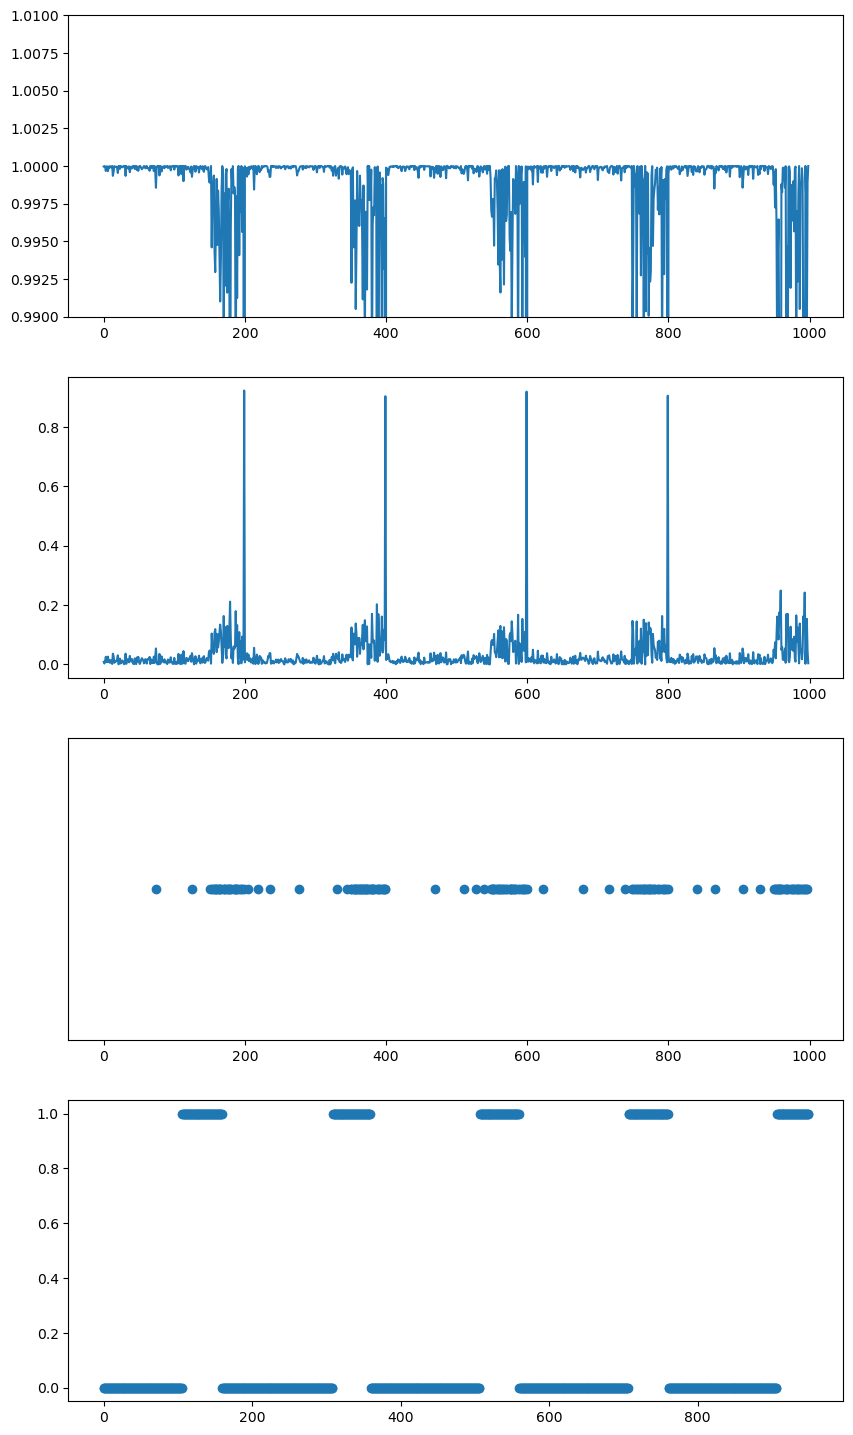

In [107]:
fig, axs = plt.subplots(nrows = 4, figsize=(10,18))
axs[0].plot(cos)
axs[0].set_ylim(0.99,1.01)
axs[1].plot(angle_displacement(ts))
axs[2].scatter(np.arange(len(sig)),sig)
axs[2].set_ylim(0.9,1.1)
axs[2].set_yticks([])
axs[3].scatter(np.arange(len(sigma)),sigma.any(axis=1).astype(int))
plt.show()

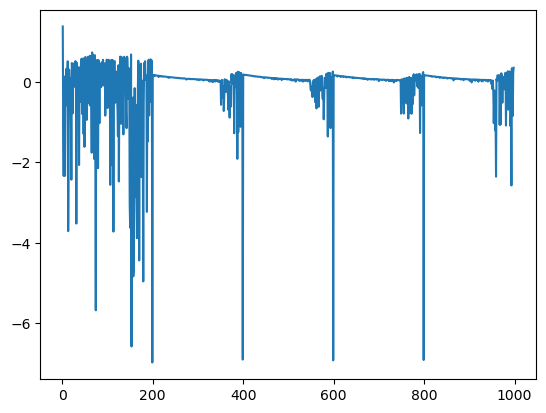

In [ ]:
plt.plot(ema_zscore(cos))